## CountVectorizer

CountVectorizer is a great tool provided by the scikit-learn library in Python. It is used to transform a given text into a vector on the basis of the frequency of each word that occurs in the entire text.

It creates a matrix in which each unique word is represented by a column of the matrix, and each text sample from the document is a row in the matrix.

Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

###### CountVectorizer
It is a great tool provided by the scikit-learn library in Python. It is used to transform a given text into a vector on the basis of the frequency of each word that occurs in the entire text.

It creates a matrix in which each unique word is represented by a column of the matrix, and each text sample from the document is a row in the matrix.




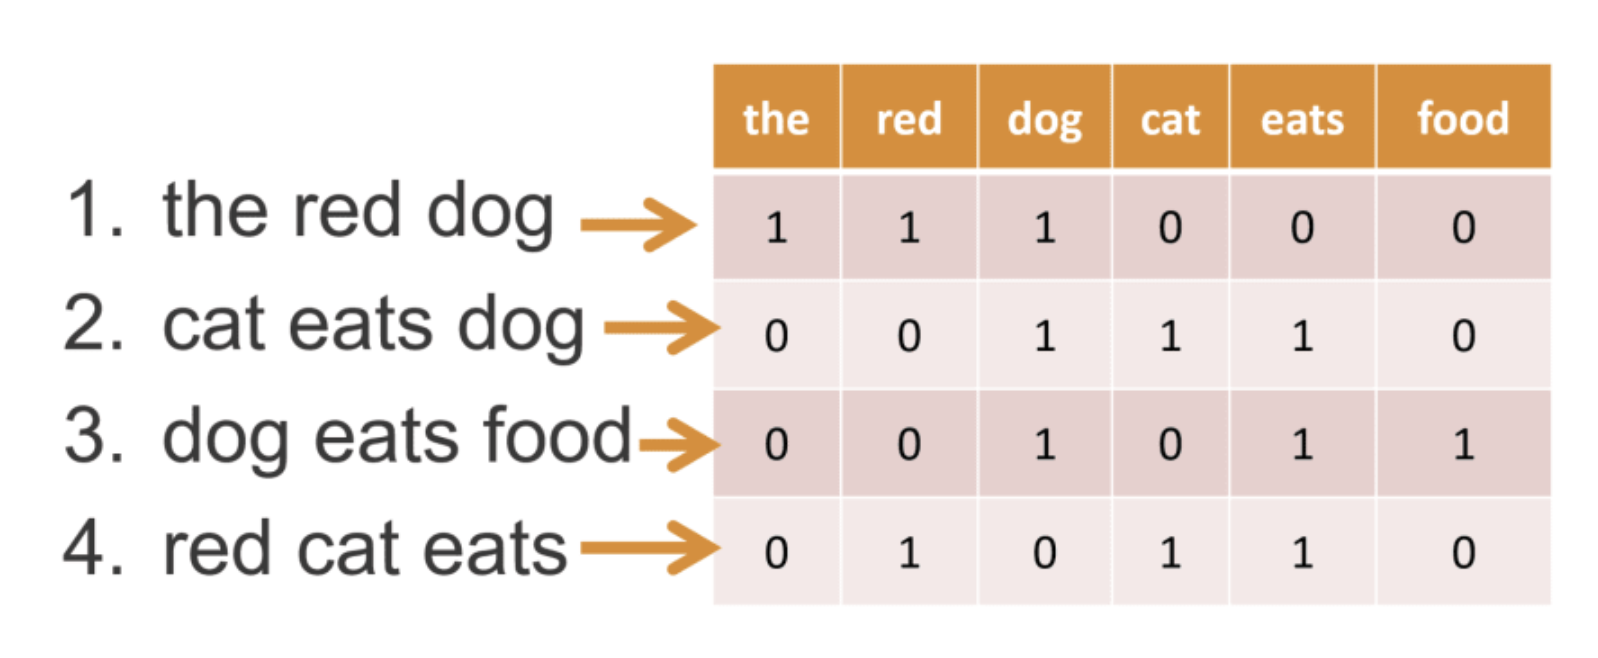

## Implementation

In [ ]:
import pandas as pd
import numpy as np
import collections
import re

In [ ]:
doc1 = 'Game of Thrones is an amazing tv series!'
doc2 = 'Game of Thrones is the best tv series!'
doc3 = 'Game of Thrones is so great'

In [ ]:
l_doc1 = re.sub(r"[^a-zA-Z0-9]", " ", doc1.lower()).split()
l_doc2 = re.sub(r"[^a-zA-Z0-9]", " ", doc2.lower()).split()
l_doc3 = re.sub(r"[^a-zA-Z0-9]", " ", doc3.lower()).split()

In [ ]:
l_doc1

['game', 'of', 'thrones', 'is', 'an', 'amazing', 'tv', 'series']

First, we instantiate a CountVectorizer object and later we learn the term frequency of each word within the document. In the end, we return the document-term matrix.

In [ ]:
text=[doc1+doc2+doc3]

In [ ]:
print(text)

['Game of Thrones is an amazing tv series!Game of Thrones is the best tv series!Game of Thrones is so great']


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer=CountVectorizer()
vectorizer.fit(text)

CountVectorizer()

Notice that by default lowercase is True.

That means, while creating tokens, CountVectorizer will change all the words in lowercase.



Call get_feature_names function to get the list of tokens.



In [ ]:
print(vectorizer.get_feature_names())

['amazing', 'an', 'best', 'game', 'great', 'is', 'of', 'series', 'so', 'the', 'thrones', 'tv']


/Users/tanvigupta/miniconda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
text

['Game of Thrones is an amazing tv series!Game of Thrones is the best tv series!Game of Thrones is so great']

In [ ]:
print(vectorizer.vocabulary_)

{'game': 3, 'of': 6, 'thrones': 10, 'is': 5, 'an': 1, 'amazing': 0, 'tv': 11, 'series': 7, 'the': 9, 'best': 2, 'so': 8, 'great': 4}


In [ ]:
vector=vectorizer.transform([doc1,doc2,doc3])

In [ ]:
vector

<3x7 sparse matrix of type '<class 'numpy.int64'>'
	with 10 stored elements in Compressed Sparse Row format>

In [ ]:
print(vector.shape)

(3, 12)


In [ ]:
vector.toarray()

array([[1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1],
       [0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0]])

Can you understand this array?

There are twenty one (representing twenty one words considered) ‘1’ spread across four rows. Each one represent a word in the text as per encoded value. To understand this array better, convert it into pandas dataframe



In [ ]:
X = vectorizer.fit_transform([doc1,doc2,doc3])
df_cv_sklearn = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names())
df_cv_sklearn.head()

,amazing,an,best,game,great,is,of,series,so,the,thrones,tv
0,1,1,0,1,0,1,1,1,0,0,1,1
1,0,0,1,1,0,1,1,1,0,1,1,1
2,0,0,0,1,1,1,1,0,1,0,1,0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform([doc1,doc2,doc3])
print(X.shape)
df_bow_sklearn = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names())
df_bow_sklearn.head()

(3, 7)


/Users/tanvigupta/miniconda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,amazing,best,game,great,series,thrones,tv
0,1,0,1,0,1,1,1
1,0,1,1,0,1,1,1
2,0,0,1,1,0,1,0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english',ngram_range=(2,2))
X = vectorizer.fit_transform([doc1,doc2,doc3])
df_cv_sklearn = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names())
df_cv_sklearn.head()

/Users/tanvigupta/miniconda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


,amazing tv,best tv,game thrones,thrones amazing,thrones best,thrones great,tv series
0,1,0,1,1,0,0,1
1,0,1,1,0,1,0,1
2,0,0,1,0,0,1,0


isn’t the combination of words interesting? It seems to make sense for “tv series”, while “game thrones” bigram loses the meaning and the word “of” since it’s a stop word. So, in some context, remove all the stop words isn’t always convenient

In [ ]:
print(vectorizer.vocabulary_)

{'game thrones': 2, 'thrones amazing': 3, 'amazing tv': 0, 'tv series': 6, 'thrones best': 4, 'best tv': 1, 'thrones great': 5}


BOWS is quite simple to implement as you can see. Of course, we only considered only unigram (single words) or bigrams(couples of words), but also trigrams can be taken into account to extract features. Stop words can be removed too as we saw, but there are still some disadvantages. The order and the meaning of the words are lost using this method. For this reason, other approaches are preferred to extract features from the text, like TF-IDF,